# Retail Sales Dataset

**Source:** [Kaggle](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset)


**Objective of this Notebook:**  
- Explore sales trends and customer behavior  
- Analyze product performance across categories  
- Identify patterns for better retail strategies  

## Import useful packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("darkgrid")

### Load data

In [2]:
data = pd.read_csv('retail_data.csv')
df = data.copy()
df.sample(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
188,189,2023-01-30,CUST189,Male,63,Beauty,1,50,50
617,618,2023-01-26,CUST618,Female,27,Beauty,1,50,50
551,552,2023-12-13,CUST552,Female,49,Electronics,3,25,75
301,302,2023-07-14,CUST302,Male,57,Beauty,2,300,600
778,779,2023-05-05,CUST779,Female,56,Electronics,2,500,1000
207,208,2023-10-04,CUST208,Female,34,Electronics,4,50,200
561,562,2023-04-18,CUST562,Male,54,Electronics,2,25,50
953,954,2023-09-25,CUST954,Female,50,Electronics,3,300,900
355,356,2023-06-10,CUST356,Male,50,Electronics,3,500,1500
399,400,2023-02-24,CUST400,Male,53,Clothing,4,50,200


In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


### Data Exploration

In [5]:
df.shape

(1000, 9)

In [6]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


#### Check for any missing values

In [8]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## Descriptive Statistics

Statistical Summary

In [9]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Check for Unique Values

In [10]:
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

Date Column

Convert date to pandas date column

In [11]:
df["Date"] = pd.to_datetime(df['Date'])

Verification

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


Create new columns from the date column

In [14]:
df["Year"] = df['Date'].dt.year
df["Month_ID"] = df['Date'].dt.month
df["Month_name"] = df['Date'].dt.month_name().str.slice(stop=3)
df["Day"] = df['Date'].dt.day
df["Weekday"] = df['Date'].dt.day_name().str.slice(stop=3)

In [15]:
df["Year"].value_counts()

Year
2023    998
2024      2
Name: count, dtype: int64

We are going to focalize only for the sales during the year 2023 since it has the most records

In [16]:
df = df[df["Year"]== 2023] 

Verification

In [17]:
df.sample(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month_ID,Month_name,Day,Weekday
493,494,2023-09-18,CUST494,Female,42,Beauty,4,50,200,2023,9,Sep,18,Mon
475,476,2023-08-29,CUST476,Female,27,Clothing,4,500,2000,2023,8,Aug,29,Tue
124,125,2023-08-08,CUST125,Male,48,Clothing,2,50,100,2023,8,Aug,8,Tue
263,264,2023-01-28,CUST264,Male,47,Clothing,3,300,900,2023,1,Jan,28,Sat
424,425,2023-05-15,CUST425,Female,55,Electronics,4,30,120,2023,5,May,15,Mon
832,833,2023-06-16,CUST833,Male,42,Beauty,4,50,200,2023,6,Jun,16,Fri
501,502,2023-04-02,CUST502,Male,43,Electronics,3,50,150,2023,4,Apr,2,Sun
615,616,2023-09-23,CUST616,Male,41,Clothing,2,50,100,2023,9,Sep,23,Sat
369,370,2023-10-16,CUST370,Male,23,Electronics,2,30,60,2023,10,Oct,16,Mon
211,212,2023-06-09,CUST212,Male,21,Clothing,3,500,1500,2023,6,Jun,9,Fri


## Sales Analysis

#### Overall Sales Overview

Total sales

In [18]:
total_sales = int(df["Total Amount"].sum())

print(f'Total sales amount is ${total_sales}')

Total sales amount is $454470


Total product quantity sold

In [19]:
total_quantity = int(df["Quantity"].sum())

print(f'Total quantity sold is {total_quantity}')


Total quantity sold is 2510


Average purchase value

In [20]:
avg_purchase = int(df["Total Amount"].mean())

print(f'Average purchase amount is ${avg_purchase}')

Average purchase amount is $455


Maximum and minimum purchase value

In [21]:
max_purchase = int(df["Total Amount"].max())
min_purchase = int(df["Total Amount"].min())

print(f'Maximum purchase amount is ${max_purchase}')
print(f'Minimum purchase amount is ${min_purchase}')

Maximum purchase amount is $2000
Minimum purchase amount is $25


##### Make Visuals

Sales per month

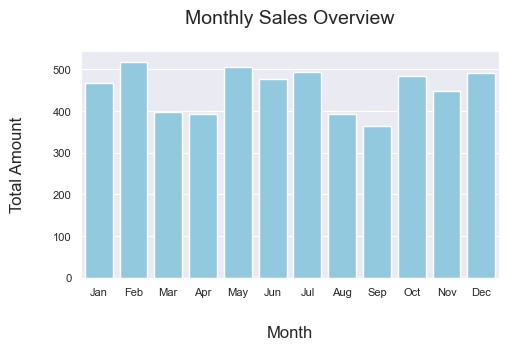

In [23]:
def sales_per_month():
    
    fig, ax = plt.subplots(figsize=(5,3))
    
    sns.barplot(data=df.sort_values("Month_ID"), 
                x="Month_name", 
                y="Total Amount", 
                color='skyblue', 
                ax=ax, 
                errorbar=None
               )
    plt.tight_layout()
    
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    ax.set_xlabel("Month", fontsize=12, labelpad=20)
    ax.set_ylabel("Total Amount", fontsize=12, labelpad=20)
    
    plt.title("Monthly Sales Overview", fontsize=14, pad=20)

    plt.savefig("Average_salesèby_month.png", bbox_inches='tight', dpi=300)
    
    plt.show()

sales_per_month()

Monthly sales trend over time

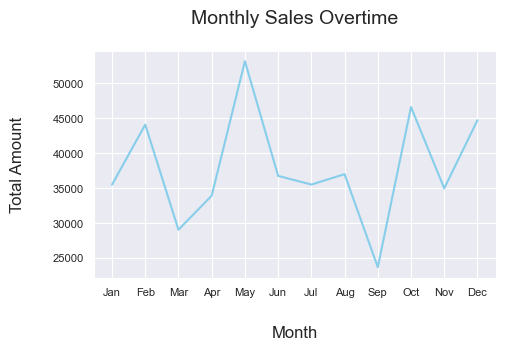

In [24]:
monthly_sales = df.groupby(['Month_ID', 'Month_name'])['Total Amount'].sum().reset_index()
monthly_sales = monthly_sales.sort_values(['Month_ID'])

def sales_over_time():
    
    fig, ax = plt.subplots(figsize=(5,3))
    
    sns.lineplot(data=monthly_sales, 
                x="Month_name", 
                y="Total Amount", 
                color='skyblue', 
                ax=ax, 
                errorbar=None
               )
    plt.tight_layout()
    
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    ax.set_xlabel("Month", fontsize=12, labelpad=20)
    ax.set_ylabel("Total Amount", fontsize=12, labelpad=20)
    
    plt.title("Monthly Sales Overtime", fontsize=14, pad=20)
    
    plt.savefig("Total_sales_by_month.png", bbox_inches='tight', dpi=300)

    plt.show()

sales_over_time()

Daily sales over Month

In [26]:
daily_sales_by_month  = df.groupby(['Month_name', 'Day'])['Total Amount'].sum().reset_index()

Visualize

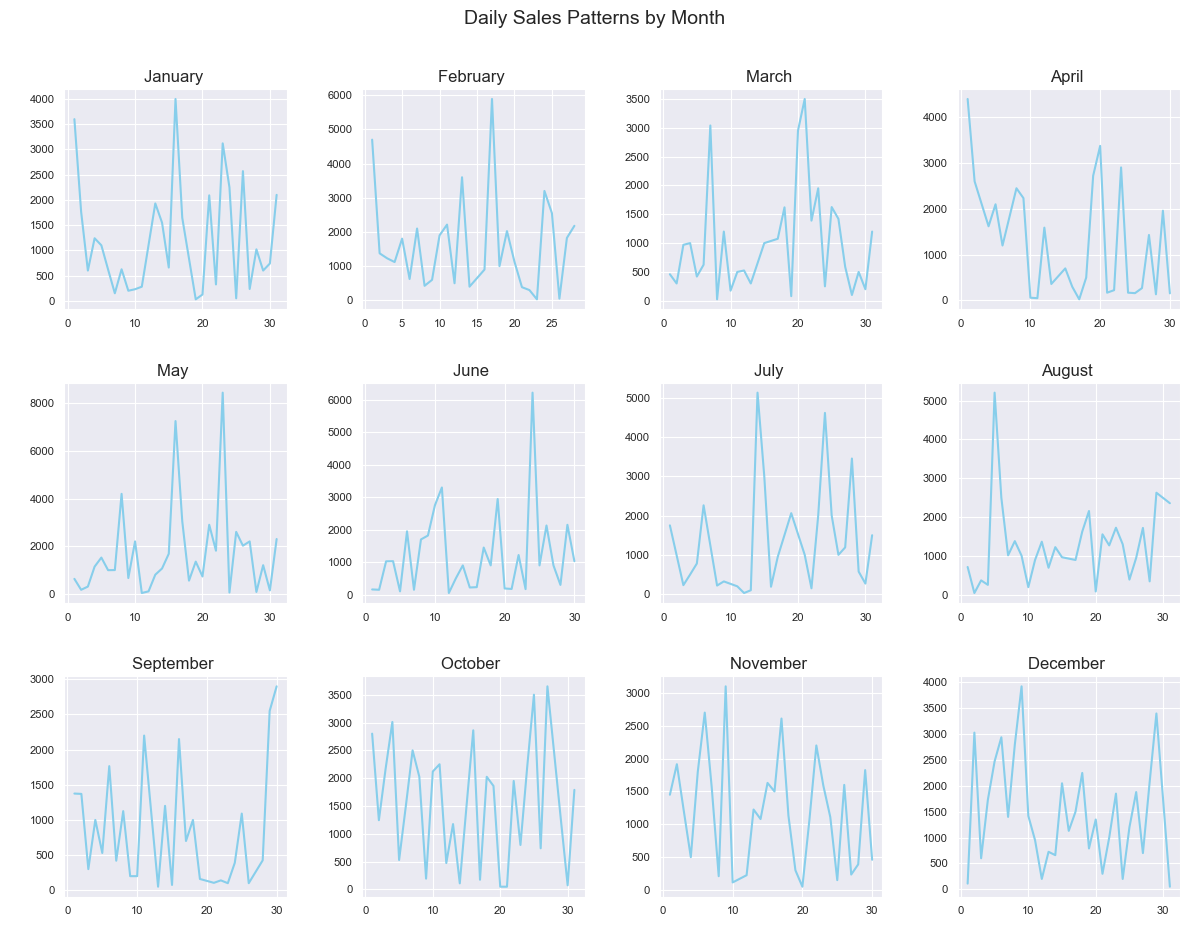

In [27]:
def plot_daily_sales_by_month():

    month_map = {
        "Jan": "January",
        "Feb": "February",
        "Mar": "March",
        "Apr": "April",
        "May": "May",
        "Jun": "June",
        "Jul": "July",
        "Aug": "August",
        "Sep": "September",
        "Oct": "October",
        "Nov": "November",
        "Dec": "December"
    }

    short_months = list(month_map.keys())
    
    rows = int(len(short_months) / 4)
    cols = 4
    
    fig, ax = plt.subplots(rows, cols, figsize=(12, 3*rows))
    
    ax = ax.flatten()
    
    for i, month in enumerate(short_months):
    
        full_month = month_map[month]
        
        sns.lineplot(
            data=daily_sales_by_month[daily_sales_by_month.Month_name == month], 
            x="Day", 
            y="Total Amount", 
            color='skyblue', 
            errorbar=None,
            ax=ax[i]
            )
        
        plt.tight_layout()
            
        ax[i].tick_params(axis='x', labelsize=8)
        ax[i].tick_params(axis='y', labelsize=8)
    
        ax[i].set_xlabel(" ")
        ax[i].set_ylabel(" ")
        
        ax[i].set_title(f"{full_month} ", fontsize=12, pad=5)
    
    fig.suptitle('Daily Sales Patterns by Month', fontsize=14, y=1.05)

    plt.savefig("total_sales_each_month.png", bbox_inches='tight', dpi=300)

    
    plt.show()

plot_daily_sales_by_month()

#### Product Category

Total sales by category

In [28]:
total_sales_by_category = df.groupby(['Product Category'])['Total Amount'].sum().reset_index().sort_values(by='Total Amount', ascending=False)
total_sales_by_category

,Product Category,Total Amount
2,Electronics,156875
1,Clothing,155580
0,Beauty,142015


Average sales by category

In [29]:
average_sales_by_category = df.groupby(['Product Category'])['Total Amount'].mean().reset_index().sort_values(by='Total Amount', ascending=False)
average_sales_by_category

,Product Category,Total Amount
0,Beauty,464.101307
2,Electronics,460.043988
1,Clothing,443.247863


Quantity sold by category

In [30]:
quantity_sold_by_category = df.groupby(['Product Category'])['Quantity'].sum().reset_index().sort_values(by='Quantity', ascending=False)
quantity_sold_by_category

,Product Category,Quantity
1,Clothing,894
2,Electronics,848
0,Beauty,768


##### Make Visuals

Price distribution per category

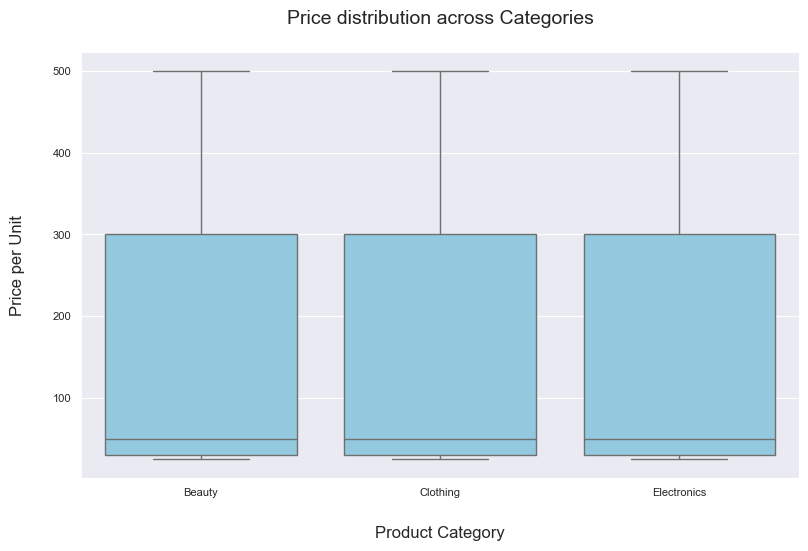

In [31]:
def plot_price_distribution():

    fig, ax = plt.subplots(figsize=(8,5))
    sns.boxplot(
        x='Product Category', 
        y='Price per Unit', 
        data=df, 
        color='skyblue'
    );
    
    plt.tight_layout()
    
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    ax.set_xlabel("Product Category", fontsize=12, labelpad=20)
    ax.set_ylabel("Price per Unit", fontsize=12, labelpad=20)
    
    plt.title("Price distribution across Categories", fontsize=14, pad=20)
    
    plt.savefig("Price_distribution.png", bbox_inches='tight', dpi=300)

    plt.show()

plot_price_distribution()

Total revenue by category

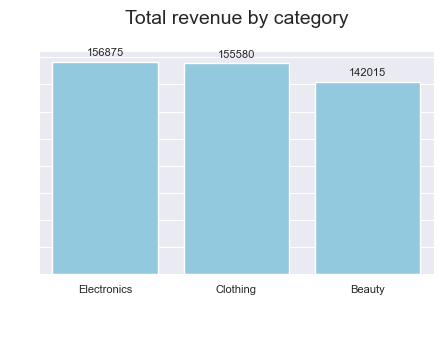

In [32]:
def plot_total_revenue_by_category():

    fig, ax = plt.subplots(figsize=(5,3))
    
    sns.barplot(
        x='Product Category', 
        y='Total Amount', 
        data=total_sales_by_category, 
        color='skyblue'
    );
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)
    
    plt.tight_layout()
    
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    ax.set_xlabel(" ", fontsize=12, labelpad=20)
    ax.set_ylabel(" ")
    
    ax.set_yticklabels([])
    
    plt.title("Total revenue by category", fontsize=14, pad=20)
    plt.savefig("Revenue_by_category.png", bbox_inches='tight', dpi=300)

    plt.show()

plot_total_revenue_by_category()

#### Customer Demographics

##### Gender-based analysis

Total spending between Male and Female.

In [33]:
total_spending_by_gender = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().reset_index()
total_spending_by_gender

,Product Category,Gender,Total Amount
0,Beauty,Female,74830
1,Beauty,Male,67185
2,Clothing,Female,81275
3,Clothing,Male,74305
4,Electronics,Female,76735
5,Electronics,Male,80140


Average spending between Male and Female.

In [34]:
average_spending_by_gender = df.groupby(['Product Category', 'Gender'])['Total Amount'].mean().reset_index()
average_spending_by_gender

,Product Category,Gender,Total Amount
0,Beauty,Female,450.783133
1,Beauty,Male,479.892857
2,Clothing,Female,467.097701
3,Clothing,Male,419.802260
4,Electronics,Female,451.382353
5,Electronics,Male,468.654971


Total quantity bought Male and Female.

In [35]:
total_quantity_by_gender = df.groupby(['Product Category', 'Gender'])['Quantity'].sum().reset_index()
total_quantity_by_gender

,Product Category,Gender,Quantity
0,Beauty,Female,418
1,Beauty,Male,350
2,Clothing,Female,441
3,Clothing,Male,453
4,Electronics,Female,439
5,Electronics,Male,409


Make visuals

Total sales by gender

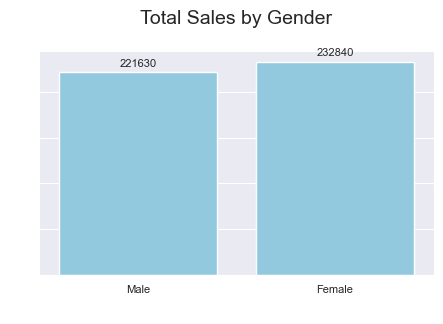

In [36]:
def plot_sales_by_gender():
    
    fig, ax = plt.subplots(figsize=(5,3))
        
    sns.barplot(data=df, 
                x="Gender", 
                y="Total Amount", 
                color='skyblue', 
                ax=ax, 
                errorbar=None,
                estimator=sum
               )
    for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)
        
    plt.tight_layout()
    
    # x and y axes
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    ax.set_xlabel(" ")
    ax.set_ylabel(" ")
    
    ax.set_yticklabels([])
    
    plt.title("Total Sales by Gender", fontsize=14, pad=20)
    plt.savefig("Sales_by_gender.png", bbox_inches='tight', dpi=300)
    
    plt.show()


plot_sales_by_gender()

Gender distribution

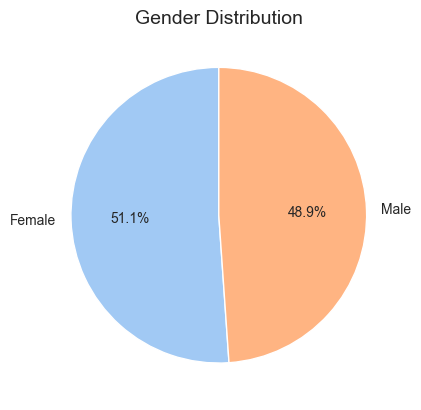

In [37]:
def plot_gender_distribution():

    df_gender_counts = df['Gender'].value_counts()
    
    colors = sns.color_palette('pastel')
    
    plt.pie(
        df_gender_counts, 
        labels=df_gender_counts.index, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=colors 
    )
    
    plt.title("Gender Distribution", fontsize=14, pad=5)
    plt.savefig("Gender_distribution.png", bbox_inches='tight', dpi=300)

    plt.show()

plot_gender_distribution()

##### Age-based analysis

Create Age group column first

In [38]:
bins = [0, 20, 30, 40, 50, 60, float('inf')]
labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']

# Create the 'Age Group' column
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
          
df

C:\Users\HP\AppData\Local\Temp\ipykernel_10416\3954324038.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month_ID,Month_name,Day,Weekday,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,Nov,24,Fri,30-39
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,Feb,27,Mon,20-29
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,Jan,13,Fri,50-59
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,21,Sun,30-39
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,6,Sat,30-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,2023,5,May,16,Tue,60+
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,2023,11,Nov,17,Fri,50-59
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,2023,10,Oct,29,Sun,20-29
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,2023,12,Dec,5,Tue,30-39


Make visuals

Total sales by age group

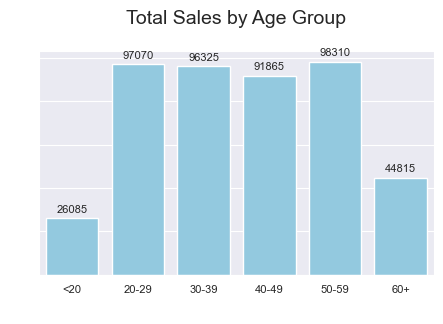

In [39]:
def plot_sales_by_age_group():
    
    fig, ax = plt.subplots(figsize=(5,3))
        
    sns.barplot(data=df, 
                x="Age Group", 
                y="Total Amount", 
                color='skyblue', 
                ax=ax, 
                errorbar=None,
                estimator=sum
               )
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)
        
    plt.tight_layout()
    
    # x and y axes
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    
    ax.set_xlabel(" ")
    ax.set_ylabel(" ")
    
    ax.set_yticklabels([])
    
    plt.title("Total Sales by Age Group", fontsize=14, pad=20)
    plt.savefig("Sales_by_age_group.png", bbox_inches='tight', dpi=300)

    plt.show()


plot_sales_by_age_group()

Distribution of customers Age

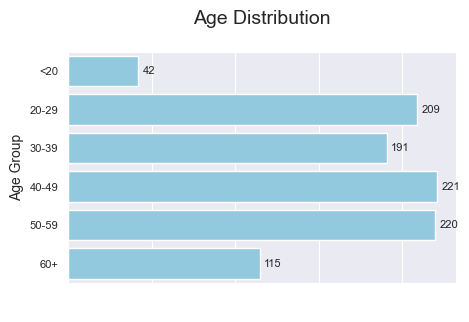

In [40]:
def plot_age_distribution():
    
    fig, ax = plt.subplots(figsize=(5,3))

    sns.countplot(y='Age Group', data=df, ax=ax, color='skyblue')
    for container in ax.containers:
            ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)

    plt.title("Age Distribution", fontsize=14, pad=20)

    # x and y axes
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    ax.set_xlabel(" ")
    ax.set_xticklabels([])

    plt.savefig("Age_distribution.png", bbox_inches='tight', dpi=300)

    plt.show()

plot_age_distribution()

##### Buying Behavior

Spending vs Age by Gender

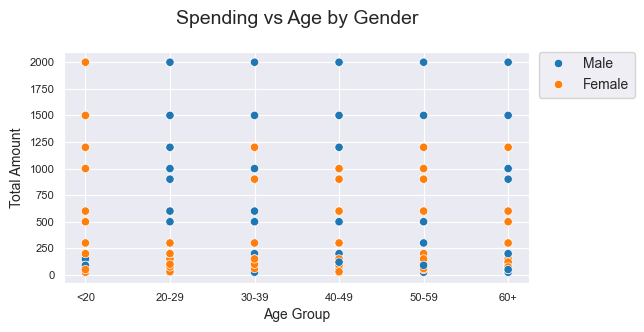

In [41]:
def plot_age_vs_spending_by_genre():
    
    fig, ax = plt.subplots(figsize=(6,3))
    sns.scatterplot(data=df, x='Age Group', y='Total Amount', hue='Gender', ax=ax, color='skyblue')


    plt.title("Spending vs Age by Gender", fontsize=14, pad=20)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

    # x and y axes
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    plt.savefig("Spending_behavior_by_age_gender.png", bbox_inches='tight', dpi=300)

    plt.show()

plot_age_vs_spending_by_genre()

Quantity vs Spending by Product Category

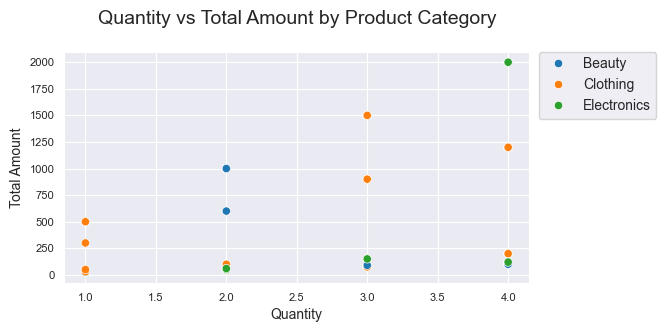

In [42]:
def plot_qty_vs_spending_by_category():
    
    fig, ax = plt.subplots(figsize=(6,3))
    sns.scatterplot(
        data=df, 
        x='Quantity', 
        y='Total Amount', 
        hue='Product Category', 
        ax=ax, 
        color='skyblue'
    )

    plt.title("Quantity vs Total Amount by Product Category", fontsize=14, pad=20)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


    # x and y axes
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    plt.savefig("Quantity_by_total_amount_by_category.png", bbox_inches='tight', dpi=300)

    plt.show()

plot_qty_vs_spending_by_category()